In [11]:
import cv2
import pytesseract
import matplotlib.pyplot as plt
import re

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

def check_license_validity(image_path):
    img = cv2.imread(image_path)
    if img is None: return "Error"
    
    img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    custom_config = r'--oem 3 --psm 6'
    extracted_text = pytesseract.image_to_string(gray, config=custom_config)
    
    print(f"OCR saw: {extracted_text.strip()}") # Let's see what it's actually reading
    
    pattern = r'[A-Z0-9]{3}.{1,2}\d{4}'
    match = re.search(pattern, extracted_text.upper())
    
    if match:
        return f"✅ Valid Format Found: {match.group()}"
    else:
        return "❌ FORGERY ALERT: No valid license ID format detected!"

print(check_license_validity("../data/fake_license.png"))

OCR saw: DRIVER LICENSE
ID; ABC-—1254
✅ Valid Format Found: ABC-—1254


OCR saw: DRIVER LICENSE
ID; ABC-—1254
✅ Valid Format Found: ABC-—1254


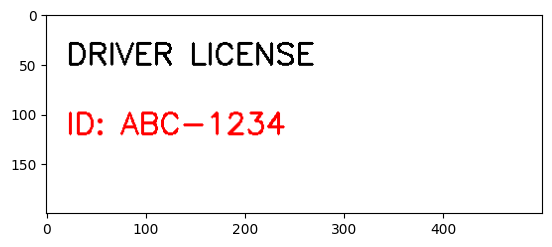

In [12]:
import numpy as np

license_img = np.ones((200, 500, 3), dtype=np.uint8) * 255

cv2.putText(license_img, "DRIVER LICENSE", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)
cv2.putText(license_img, "ID: ABC-1234", (20, 120), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

cv2.imwrite("../data/fake_license.png", license_img)

result = check_license_validity("../data/fake_license.png")
print(result)

plt.imshow(cv2.cvtColor(license_img, cv2.COLOR_BGR2RGB))
plt.show()